# POC SOC Triage — 04 XAI (Explainability)

**Objectif** : générer les explications XAI pour chaque incident — ce que verra l'analyste N1.

- **SHAP global** : quelles features comptent le plus pour le modèle ?
- **SHAP local** : pourquoi cet incident a-t-il ce score ?
- **Counterfactual** : qu'est-ce qui aurait changé la décision ?

**Output** : `shap_values_sample.pkl` + figures d'explication


In [166]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import shap
import joblib
import warnings
import xgboost as xgb
warnings.filterwarnings('ignore', category=FutureWarning)
from pathlib import Path

DATA_DIR = Path('data')
MODEL_DIR = Path('models')

print(f'SHAP version: {shap.__version__}')

SHAP version: 0.46.0


## 0. Chargement des données et du modèle

In [167]:
# Chargement autonome — ce notebook peut tourner indépendamment du 03_
# (pas besoin d'avoir le 03_ en mémoire)

import pickle

# ── Config d'inférence sauvegardée par le 03_ ─────────────────────────────────
with open(MODEL_DIR / 'inference_config.pkl', 'rb') as f:
    inference_config = pickle.load(f)

FEATURE_COLS = inference_config['feature_cols']
print(f'FEATURE_COLS chargés : {len(FEATURE_COLS)} features')

# ── Dataset ML (features + target) ────────────────────────────────────────────
df_full = pd.read_parquet(DATA_DIR / 'features_ml.parquet')
X_full  = df_full[FEATURE_COLS].values
y_full  = df_full['target'].values

# ── Sample de 500 incidents pour la démo (produit par le 03_) ─────────────────
df_sample = pd.read_csv(DATA_DIR / 'predictions_sample.csv')

# Récupérer les features ML du sample depuis df_full (jointure sur IncidentId)
df_sample_feat = df_full[df_full['IncidentId'].isin(df_sample['IncidentId'])].copy()
df_sample_feat = df_sample_feat.set_index('IncidentId').reindex(df_sample['IncidentId']).reset_index()
X_sample = df_sample_feat[FEATURE_COLS].values

# Enrichir df_sample avec les features ML pour les waterfall plots
for col in FEATURE_COLS:
    if col not in df_sample.columns:
        df_sample[col] = df_sample_feat[col].values

print(f'Dataset complet  : {len(df_full):,} incidents')
print(f'Sample démo      : {len(df_sample):,} incidents')
print(f'X_full shape     : {X_full.shape}')
print(f'X_sample shape   : {X_sample.shape}')


FEATURE_COLS chargés : 83 features
Dataset complet  : 30,000 incidents
Sample démo      : 500 incidents
X_full shape     : (30000, 83)
X_sample shape   : (500, 83)


## 1. SHAP — Calcul des valeurs

In [168]:
# Chargement du booster natif — évite le problème de désérialisation BoosterWrapper
booster = xgb.Booster()
booster.load_model(str(MODEL_DIR / 'xgboost_booster.json'))

# Recréer le wrapper pour predict_proba
class BoosterWrapper:
    def __init__(self, booster, feature_names, n_classes=3):
        self.booster        = booster
        self.feature_names  = feature_names
        self.n_classes      = n_classes
        self.n_features_in_ = len(feature_names)
        scores = booster.get_score(importance_type='gain')
        imp = np.zeros(len(feature_names))
        for k, v in scores.items():
            idx = int(k[1:]) if k.startswith('f') else feature_names.index(k)
            imp[idx] = v
        self.feature_importances_ = imp / imp.sum() if imp.sum() > 0 else imp

    def predict_proba(self, X):
        dm = xgb.DMatrix(X, feature_names=self.feature_names)
        proba = self.booster.predict(dm)
        return proba.reshape(-1, self.n_classes)

    def predict(self, X):
        return self.predict_proba(X).argmax(axis=1)

    def get_booster(self):
        return self.booster

xgb_model = BoosterWrapper(booster, FEATURE_COLS)
explainer  = shap.TreeExplainer(booster)  # directement le booster natif
print(f'Modèle chargé — {len(FEATURE_COLS)} features')

Modèle chargé — 83 features


In [169]:
print('Calcul des SHAP values (TreeExplainer — rapide pour XGBoost)...')
explainer = shap.TreeExplainer(booster)  # booster natif, pas le wrapper

# SHAP global sur tous les incidents — pour les graphiques d'importance
print('  → SHAP global (dataset complet)...')
shap_values_raw_full = explainer.shap_values(X_full)

# SHAP local sur les 500 incidents de la démo — pour les waterfall et explications
print('  → SHAP local (dataset démo 500)...')
shap_values_raw_sample = explainer.shap_values(X_sample)

# Normalisation : gère les deux formats selon la version de SHAP
def normalize_shap(shap_raw):
    if isinstance(shap_raw, list):
        return shap_raw  # [0]=FP, [1]=BP, [2]=TP
    else:
        return [shap_raw[:, :, i] for i in range(shap_raw.shape[2])]

shap_values_full   = normalize_shap(shap_values_raw_full)
shap_values_sample = normalize_shap(shap_values_raw_sample)

# shap_tp_full  : contributions vers TP sur tous les incidents (pour SHAP global)
# shap_tp_sample : contributions vers TP sur les 500 incidents (pour waterfall + explications)
shap_tp_full   = shap_values_full[2]
shap_tp_sample = shap_values_sample[2]

# Alias pour compatibilité avec le reste du notebook
shap_values = shap_values_sample
shap_tp     = shap_tp_sample

print(f'SHAP global  : {shap_tp_full.shape}')
print(f'SHAP démo    : {shap_tp_sample.shape}')

# Sauvegarde pour la démo Streamlit
# On sauvegarde les SHAP du sample (500) — utilisés par le 05_ pour les waterfall
joblib.dump({
    'shap_values':    shap_values_sample,
    'feature_names':  FEATURE_COLS,
    'X_sample':       X_sample,
    'incident_ids':   df_sample['IncidentId'].values
}, DATA_DIR / 'shap_values_sample.pkl')
print('✅ shap_values_sample.pkl sauvegardé')

Calcul des SHAP values (TreeExplainer — rapide pour XGBoost)...
  → SHAP global (dataset complet)...
  → SHAP local (dataset démo 500)...
SHAP global  : (30000, 83)
SHAP démo    : (500, 83)
✅ shap_values_sample.pkl sauvegardé


## 2. SHAP global — Importance des features pour la classe TP

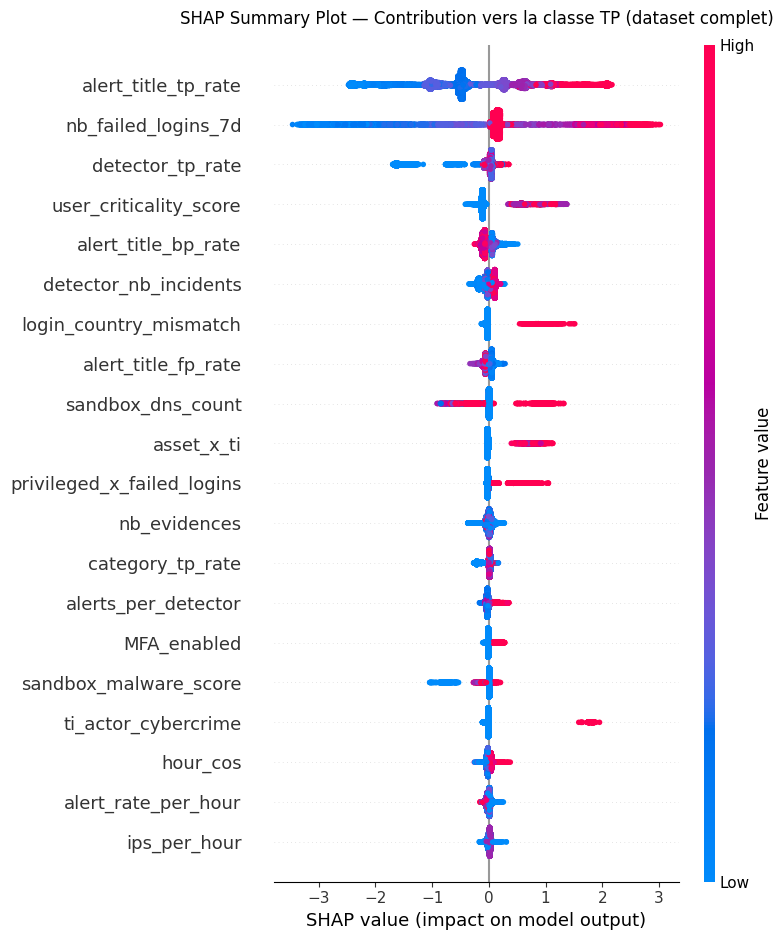

→ Points rouges = valeur élevée de la feature → pousse vers TP
  Points bleus = valeur faible → tire vers FP


In [170]:
# SHAP summary plot pour la classe TP — basé sur tous les incidents
# (plus représentatif que les 500 du sample)
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_tp_full, X_full, feature_names=FEATURE_COLS,
                  plot_type='dot', max_display=20, show=False)
plt.title('SHAP Summary Plot — Contribution vers la classe TP (dataset complet)', pad=15)
plt.tight_layout()
plt.savefig(DATA_DIR / 'shap_summary_tp.png', dpi=120, bbox_inches='tight')
plt.show()
print('→ Points rouges = valeur élevée de la feature → pousse vers TP')
print('  Points bleus = valeur faible → tire vers FP')

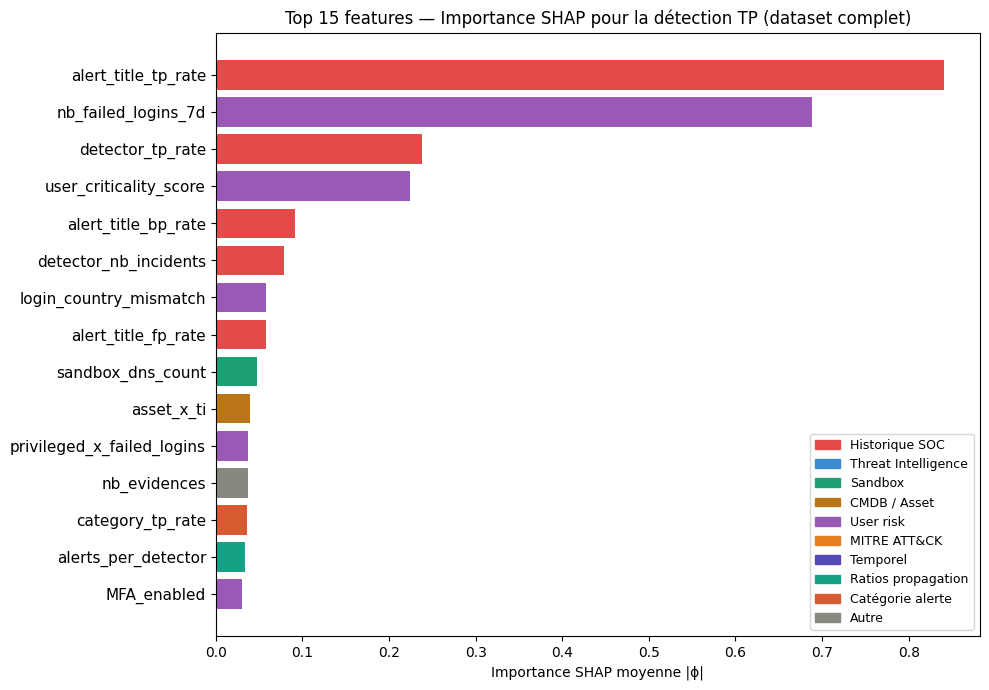

In [171]:
# Bar plot de l'importance SHAP moyenne — basé sur tous les incidents
mean_abs_shap = np.abs(shap_tp_full).mean(axis=0)
shap_importance = pd.Series(mean_abs_shap, index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
top_n = 15
top_shap = shap_importance.head(top_n)

# Couleurs par famille — nouvelles familles ajoutées (MITRE, user risk, ratios)
def get_family_color(feat_name):
    if any(k in feat_name for k in ['detector_', 'alert_title_']):
        return '#E24B4A'  # SOC historique
    elif any(k in feat_name for k in ['ti_', 'ip_ti', 'hash_ti', 'blocklist',
                                       'ti_actor', 'ti_score']):
        return '#3B8BD4'  # Threat Intelligence
    elif 'sandbox' in feat_name:
        return '#1D9E75'  # Sandbox
    elif any(k in feat_name for k in ['asset_x_', 'asset_']):
        return '#BA7517'  # CMDB asset + interactions
    elif any(k in feat_name for k in ['user_', 'is_privileged', 'account_',
                                       'MFA', 'nb_failed_logins', 'login_country',
                                       'privileged_x_']):
        return '#9B59B6'  # User risk (CMDB user + interactions)
    elif 'mitre_' in feat_name:
        return '#E67E22'  # MITRE ATT&CK
    elif 'category_' in feat_name:
        return '#D85A30'  # Catégorie alerte
    elif any(k in feat_name for k in ['hour', 'day', 'weekend', 'duration',
                                       'is_after_midnight', 'is_business']):
        return '#534AB7'  # Temporel
    elif any(k in feat_name for k in ['spread', 'accounts_per', 'ips_per',
                                       'alerts_per', 'has_impacted', 'nb_impacted']):
        return '#16A085'  # Ratios propagation
    else:
        return '#888780'  # Autre

colors_shap = [get_family_color(f) for f in top_shap.index]
bars = ax.barh(range(top_n), top_shap.values, color=colors_shap)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_shap.index, fontsize=11)
ax.invert_yaxis()
ax.set_xlabel('Importance SHAP moyenne |ϕ|')
ax.set_title('Top 15 features — Importance SHAP pour la détection TP (dataset complet)')

legend_patches = [
    mpatches.Patch(color='#E24B4A', label='Historique SOC'),
    mpatches.Patch(color='#3B8BD4', label='Threat Intelligence'),
    mpatches.Patch(color='#1D9E75', label='Sandbox'),
    mpatches.Patch(color='#BA7517', label='CMDB / Asset'),
    mpatches.Patch(color='#9B59B6', label='User risk'),
    mpatches.Patch(color='#E67E22', label='MITRE ATT&CK'),
    mpatches.Patch(color='#534AB7', label='Temporel'),
    mpatches.Patch(color='#16A085', label='Ratios propagation'),
    mpatches.Patch(color='#D85A30', label='Catégorie alerte'),
    mpatches.Patch(color='#888780', label='Autre'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(DATA_DIR / 'shap_importance_bar.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. SHAP local — Explication d'un incident critique
**C'est ce que verra l'analyste N1 dans la démo.**

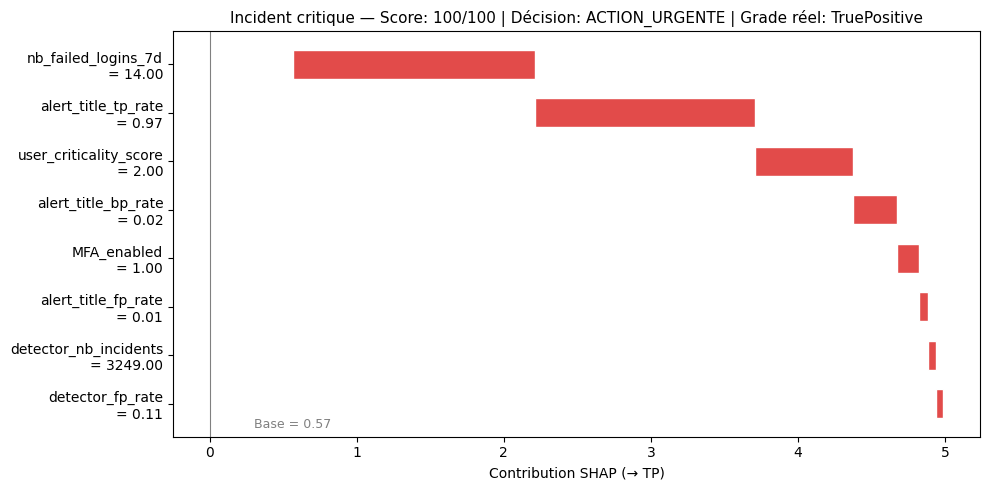

Top contributions pour cet incident :
nb_failed_logins_7d       1.6457
alert_title_tp_rate       1.4970
user_criticality_score    0.6667
alert_title_bp_rate       0.2971
MFA_enabled               0.1485
alert_title_fp_rate       0.0611
detector_nb_incidents     0.0539
detector_fp_rate          0.0511
dtype: float32


In [172]:
def explain_incident(incident_idx, title_prefix=''):
    """Génère le waterfall plot SHAP pour un incident donné (index positionnel dans df_sample)."""
    incident = df_sample.iloc[incident_idx]
    shap_local = shap_tp[incident_idx]  # contributions pour la classe TP

    # Top features contributives
    contrib = pd.Series(shap_local, index=FEATURE_COLS).sort_values(key=abs, ascending=False)
    top_contrib = contrib.head(8)

    fig, ax = plt.subplots(figsize=(10, 5))

    # Waterfall chart manuel
    base_value = explainer.expected_value[2]
    cumulative = base_value
    bar_positions = []
    bar_heights = []
    bar_colors = []
    bar_labels = []

    for feat_name, contrib_val in top_contrib.items():
        feat_val = df_sample.iloc[incident_idx][feat_name]
        bar_positions.append(cumulative + contrib_val / 2)
        bar_heights.append(contrib_val)
        bar_colors.append('#E24B4A' if contrib_val > 0 else '#3B8BD4')
        bar_labels.append(f'{feat_name}\n= {feat_val:.2f}')
        cumulative += contrib_val

    # Affichage
    y_pos = range(len(bar_heights))
    bars = ax.barh(list(y_pos), bar_heights, left=[p - h/2 for p, h in zip(bar_positions, bar_heights)],
                   color=bar_colors, height=0.6, edgecolor='white')

    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(bar_labels, fontsize=10)
    ax.invert_yaxis()
    ax.axvline(0, color='gray', linewidth=0.8)
    ax.set_xlabel('Contribution SHAP (→ TP)')

    score = incident['priority_score']
    decision = incident['decision_suggested']
    grade = incident.get('grade_reel_label', '?')
    ax.set_title(f'{title_prefix}Score: {score:.0f}/100 | Décision: {decision} | Grade réel: {grade}',
                 fontsize=11)

    # Valeur de base
    ax.text(base_value, len(bar_heights) - 0.5, f'Base = {base_value:.2f}',
            ha='center', color='gray', fontsize=9)

    plt.tight_layout()
    return fig, top_contrib

# Incident avec le score le plus élevé (indice positionnel direct)
max_score_idx = df_sample['priority_score'].values.argmax()
fig, contrib = explain_incident(max_score_idx, title_prefix='Incident critique — ')
plt.savefig(DATA_DIR / 'shap_waterfall_critique.png', dpi=120, bbox_inches='tight')
plt.show()

print('Top contributions pour cet incident :')
print(contrib.round(4))

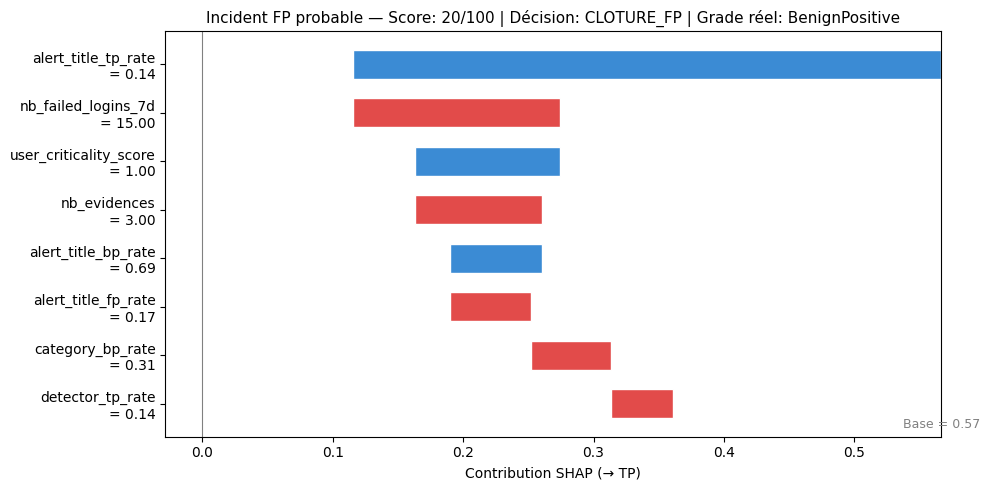


Contributions pour le FP probable :
alert_title_tp_rate      -0.4515
nb_failed_logins_7d       0.1588
user_criticality_score   -0.1115
nb_evidences              0.0975
alert_title_bp_rate      -0.0699
alert_title_fp_rate       0.0620
category_bp_rate          0.0610
detector_tp_rate          0.0474
dtype: float32


In [173]:
# Exemple : un incident FP probable pour contraste
fp_candidates = df_sample[df_sample['decision_suggested'] == 'CLOTURE_FP']
if len(fp_candidates) > 0:
    fp_pos = df_sample.index.get_loc(fp_candidates.index[0])  # index positionnel (reset_index garantit 0..N-1)
    fig, contrib_fp = explain_incident(fp_pos, title_prefix='Incident FP probable — ')
    plt.savefig(DATA_DIR / 'shap_waterfall_fp.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('\nContributions pour le FP probable :')
    print(contrib_fp.round(4))

## 4. Counterfactual — "Qu'est-ce qui aurait changé la décision ?"

Pour chaque incident, on identifie la feature la plus influente et on montre le seuil auquel la décision basculerait.

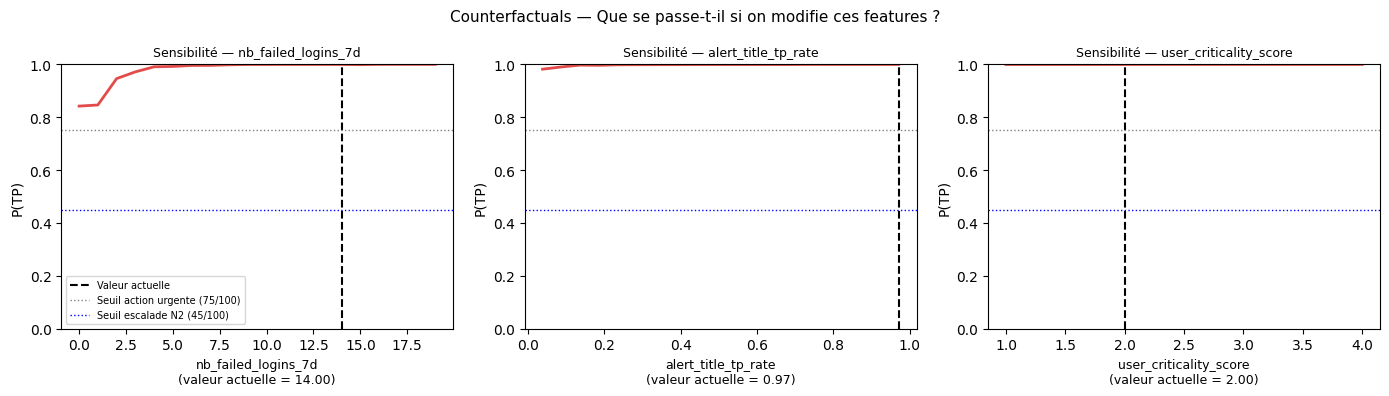

In [174]:
def compute_counterfactual(incident_idx, target_class=2, delta_steps=20):
    """
    Pour chaque feature dans le top 5, fait varier la valeur sur son étendue réelle
    et mesure l'impact sur la probabilité TP.
    """
    x_orig = X_sample[incident_idx].copy()
    shap_local = shap_tp[incident_idx]
    top_features = pd.Series(shap_local, index=FEATURE_COLS).abs().nlargest(5).index.tolist()

    results = []
    for feat_name in top_features:
        feat_idx = FEATURE_COLS.index(feat_name)
        orig_val = x_orig[feat_idx]

        # Bornes réelles observées dans les données (évite les valeurs hors-distribution)
        feat_min = X_sample[:, feat_idx].min()
        feat_max = X_sample[:, feat_idx].max()
        feat_range = np.linspace(feat_min, feat_max, delta_steps)

        scores = []
        for val in feat_range:
            x_mod = x_orig.copy()
            x_mod[feat_idx] = val
            prob_tp = xgb_model.predict_proba([x_mod])[0][2]
            scores.append(prob_tp)

        results.append({
            'feature': feat_name,
            'orig_val': orig_val,
            'orig_proba_tp': xgb_model.predict_proba([x_orig])[0][2],
            'feat_range': feat_range,
            'proba_tp_range': scores,
        })
    return results

# Counterfactual sur l'incident critique
cf_results = compute_counterfactual(max_score_idx)

# Seuils de probabilité TP (priority_score = prob_tp × 100 dans 03_ml_models)
SEUIL_ACTION_URGENTE_PROB = 0.75
SEUIL_ESCALADE_N2_PROB = 0.45

fig, axes = plt.subplots(1, min(3, len(cf_results)), figsize=(14, 4))
if len(cf_results) == 1:
    axes = [axes]

for i, (result, ax) in enumerate(zip(cf_results[:3], axes)):
    ax.plot(result['feat_range'], result['proba_tp_range'], color='#E24B4A', lw=2)
    ax.axvline(result['orig_val'], color='black', linestyle='--', lw=1.5, label='Valeur actuelle')
    ax.axhline(SEUIL_ACTION_URGENTE_PROB, color='gray', linestyle=':', lw=1, label='Seuil action urgente (75/100)')
    ax.axhline(SEUIL_ESCALADE_N2_PROB, color='blue', linestyle=':', lw=1, label='Seuil escalade N2 (45/100)')
    ax.set_xlabel(f'{result["feature"]}\n(valeur actuelle = {result["orig_val"]:.2f})', fontsize=9)
    ax.set_ylabel('P(TP)')
    ax.set_ylim(0, 1)
    ax.set_title(f'Sensibilité — {result["feature"][:30]}', fontsize=9)
    if i == 0:
        ax.legend(fontsize=7)

plt.suptitle('Counterfactuals — Que se passe-t-il si on modifie ces features ?', fontsize=11)
plt.tight_layout()
plt.savefig(DATA_DIR / 'counterfactuals.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. LIME — Explication locale par modèle linéaire

**Principe** : LIME (Local Interpretable Model-agnostic Explanations) crée une explication locale en perturbant les valeurs d'un incident et en entraînant un modèle linéaire simple sur ces perturbations. Contrairement à SHAP qui calcule des contributions exactes, LIME produit une approximation linéaire locale — "si cette feature augmentait, le score augmenterait de X".

**Complémentarité avec SHAP** :
- SHAP est exact mais peut être difficile à interpréter pour un non-expert
- LIME produit une explication narrative plus intuitive ("les 5 raisons principales")
- Les deux devraient converger sur les mêmes features importantes — si ce n'est pas le cas, c'est un signal que l'incident est dans une zone complexe du modèle

**Usage SOC** : LIME est particulièrement utile pour les incidents borderline (score entre 45 et 75) où l'analyste a besoin de comprendre précisément pourquoi le modèle hésite avant de prendre une décision.

Calcul LIME pour l'incident critique (peut prendre quelques secondes)...


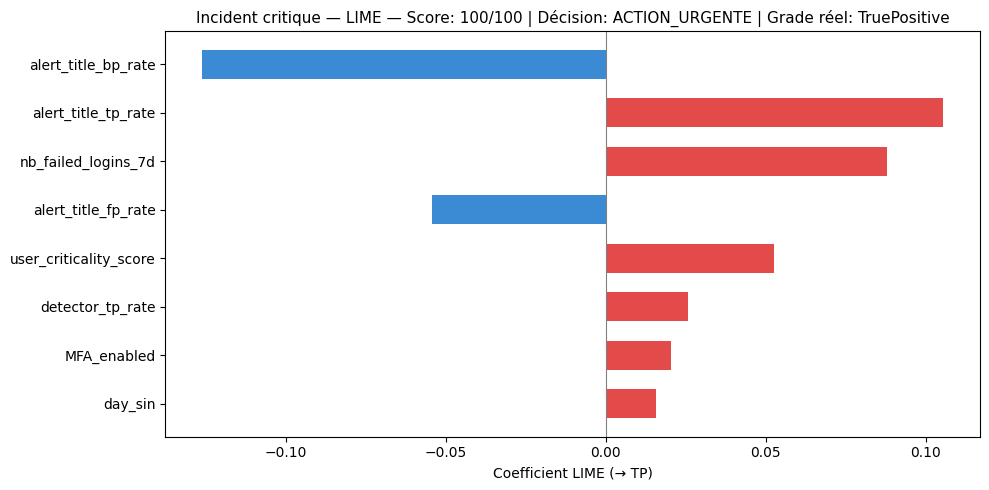


Explication LIME (classe TP) :
  ↓ TP  alert_title_bp_rate  (coeff=-0.1261)
  ↑ TP  alert_title_tp_rate  (coeff=0.1054)
  ↑ TP  nb_failed_logins_7d  (coeff=0.0880)
  ↓ TP  alert_title_fp_rate  (coeff=-0.0544)
  ↑ TP  user_criticality_score  (coeff=0.0524)
  ↑ TP  detector_tp_rate  (coeff=0.0257)
  ↑ TP  MFA_enabled  (coeff=0.0203)
  ↑ TP  day_sin  (coeff=0.0157)


In [175]:
# Installation si nécessaire : pip install lime
from lime.lime_tabular import LimeTabularExplainer

# ── Initialisation de l'explainer LIME ────────────────────────────────────────
# IMPORTANT : discretize_continuous=False — évite le bug où LIME remplace
# les noms de features par leurs indices (ex: "13 > 2.50" au lieu de
# "nb_alerts > 2.50"). Ce bug survient quand la discrétisation interne
# de LIME perd le mapping index → nom fourni par feature_names.
lime_explainer = LimeTabularExplainer(
    training_data         = X_full,
    feature_names         = FEATURE_COLS,          # noms explicites des features
    class_names           = ['FalsePositive', 'BenignPositive', 'TruePositive'],
    mode                  = 'classification',
    discretize_continuous = False,   # False = évite le bug d'indices numériques
    random_state          = 42,
)

def explain_incident_lime(incident_idx, n_features=8, title_prefix=''):
    """
    Génère une explication LIME pour un incident du sample.
    
    LIME perturbe les valeurs de l'incident (en échantillonnant autour de lui)
    et entraîne un modèle linéaire local pour approximer le comportement de XGBoost
    dans ce voisinage. Les coefficients de ce modèle linéaire sont l'explication.
    
    n_features : nb de features à afficher dans l'explication
    """
    x_incident = X_sample[incident_idx]
    incident   = df_sample.iloc[incident_idx]
    
    # predict_fn : LIME passe un numpy array — on le convertit en DMatrix
    # avec les feature_names explicites pour que XGBoost garde les noms corrects.
    # Ne PAS utiliser xgb_model.predict_proba directement — XGBoost peut ignorer
    # les feature_names si le wrapper ne les transmet pas correctement.
    def lime_predict(X_perturbed):
        dm = xgb.DMatrix(
            np.array(X_perturbed, dtype=np.float32),
            feature_names=FEATURE_COLS   # noms explicites à chaque appel
        )
        proba = booster.predict(dm)
        return proba.reshape(-1, 3)
    
    lime_exp = lime_explainer.explain_instance(
        data_row       = x_incident.astype(np.float64),  # float64 requis par LIME
        predict_fn     = lime_predict,
        num_features   = n_features,
        top_labels     = 3,
        num_samples    = 500,
    )
    
    # Explication pour la classe TP (label 2)
    exp_tp = lime_exp.as_list(label=2)
    
    # Visualisation
    fig, ax = plt.subplots(figsize=(10, 5))
    features_lime = [x[0] for x in exp_tp]
    weights_lime  = [x[1] for x in exp_tp]
    colors_lime   = ['#E24B4A' if w > 0 else '#3B8BD4' for w in weights_lime]
    
    ax.barh(range(len(weights_lime)), weights_lime, color=colors_lime, height=0.6)
    ax.set_yticks(range(len(features_lime)))
    ax.set_yticklabels(features_lime, fontsize=10)
    ax.invert_yaxis()
    ax.axvline(0, color='gray', linewidth=0.8)
    ax.set_xlabel('Coefficient LIME (→ TP)')
    
    score    = incident['priority_score']
    decision = incident['decision_suggested']
    grade    = incident.get('grade_reel_label', '?')
    ax.set_title(f'{title_prefix}LIME — Score: {score:.0f}/100 | '
                 f'Décision: {decision} | Grade réel: {grade}', fontsize=11)
    
    plt.tight_layout()
    return fig, exp_tp, lime_exp

# ── Explication LIME pour l'incident critique ──────────────────────────────────
print("Calcul LIME pour l'incident critique (peut prendre quelques secondes)...")
fig_lime_crit, exp_tp_crit, lime_obj_crit = explain_incident_lime(
    max_score_idx, title_prefix='Incident critique — '
)
plt.savefig(DATA_DIR / 'lime_critique.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nExplication LIME (classe TP) :")
for feat_rule, weight in exp_tp_crit:
    direction = "↑ TP" if weight > 0 else "↓ TP"
    print(f"  {direction}  {feat_rule}  (coeff={weight:.4f})")


Comparaison SHAP vs LIME — incident critique
  Top 8 SHAP : ['nb_failed_logins_7d', 'alert_title_tp_rate', 'user_criticality_score', 'alert_title_bp_rate', 'MFA_enabled', 'alert_title_fp_rate', 'detector_nb_incidents', 'detector_fp_rate']
  Top 8 LIME : ['alert_title_bp_rate', 'alert_title_tp_rate', 'nb_failed_logins_7d', 'alert_title_fp_rate', 'user_criticality_score', 'detector_tp_rate', 'MFA_enabled', 'day_sin']
  Features communes : ['MFA_enabled', 'alert_title_bp_rate', 'alert_title_fp_rate', 'alert_title_tp_rate', 'nb_failed_logins_7d', 'user_criticality_score'] (6/8)

✓ Bonne convergence SHAP/LIME — explication cohérente et fiable


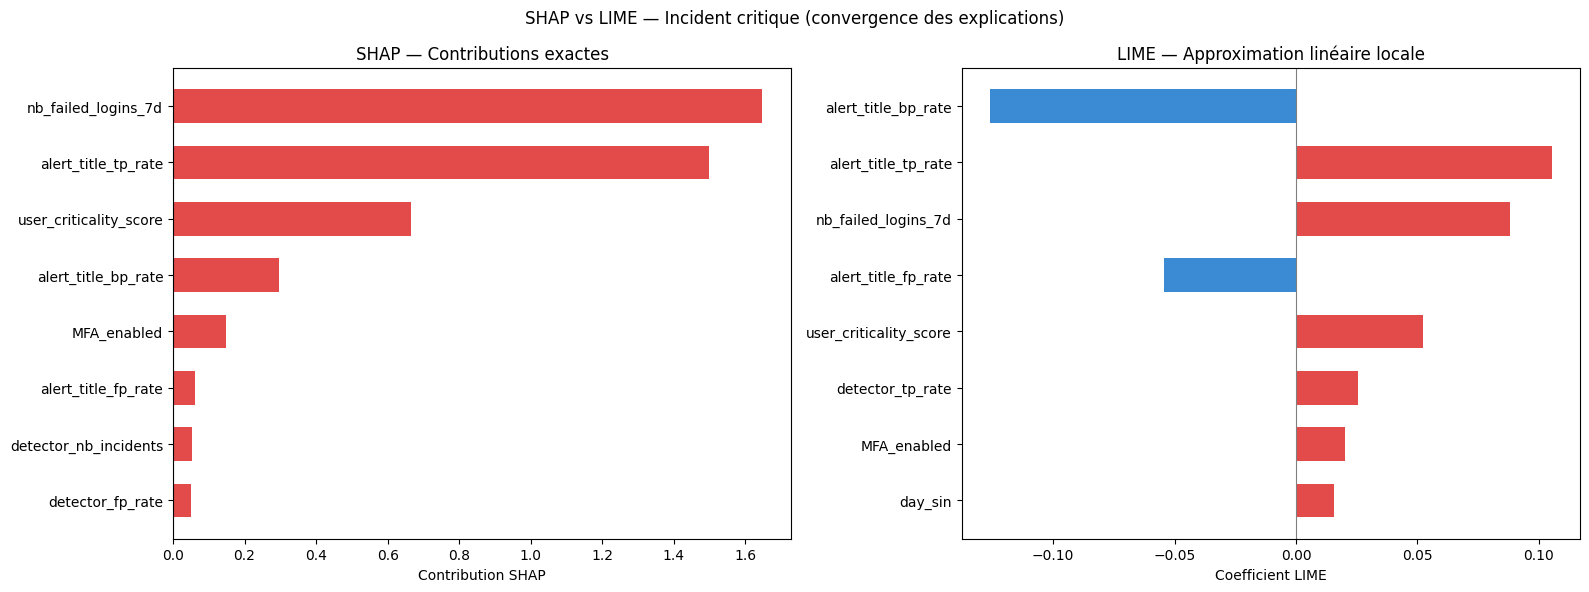

In [176]:
# ── Comparaison SHAP vs LIME sur le même incident ────────────────────────────
# Les deux méthodes devraient identifier les mêmes features importantes.
# Une divergence signale que l'incident est dans une zone non-linéaire complexe.

shap_local = shap_tp_sample[max_score_idx]
shap_contrib = pd.Series(shap_local, index=FEATURE_COLS).abs().sort_values(ascending=False)

# Extraire les feature names depuis les règles LIME (ex: "alert_title_fp_rate > 0.30")
lime_features = [rule.split(' ')[0] for rule, _ in exp_tp_crit]
shap_top_features = shap_contrib.head(len(lime_features)).index.tolist()

# Overlap : features communes dans le top N des deux méthodes
overlap = set(lime_features) & set(shap_top_features)
print(f"Comparaison SHAP vs LIME — incident critique")
print(f"  Top {len(lime_features)} SHAP : {shap_top_features}")
print(f"  Top {len(lime_features)} LIME : {lime_features}")
print(f"  Features communes : {sorted(overlap)} ({len(overlap)}/{len(lime_features)})")
print()

if len(overlap) / len(lime_features) >= 0.6:
    print("✓ Bonne convergence SHAP/LIME — explication cohérente et fiable")
else:
    print("⚠ Divergence SHAP/LIME — incident dans une zone complexe du modèle")
    print("  → L'analyste SOC devrait investiguer manuellement cet incident")

# Visualisation côte à côte
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# SHAP (gauche)
top_shap_local = pd.Series(shap_local, index=FEATURE_COLS).sort_values(key=abs, ascending=False).head(8)
colors_s = ['#E24B4A' if v > 0 else '#3B8BD4' for v in top_shap_local.values]
axes[0].barh(range(len(top_shap_local)), top_shap_local.values, color=colors_s, height=0.6)
axes[0].set_yticks(range(len(top_shap_local)))
axes[0].set_yticklabels(top_shap_local.index, fontsize=10)
axes[0].invert_yaxis()
axes[0].axvline(0, color='gray', linewidth=0.8)
axes[0].set_xlabel('Contribution SHAP')
axes[0].set_title('SHAP — Contributions exactes')

# LIME (droite)
lime_feat_names = [r.split(' ')[0] for r, _ in exp_tp_crit[:8]]
lime_weights    = [w for _, w in exp_tp_crit[:8]]
colors_l = ['#E24B4A' if w > 0 else '#3B8BD4' for w in lime_weights]
axes[1].barh(range(len(lime_weights)), lime_weights, color=colors_l, height=0.6)
axes[1].set_yticks(range(len(lime_feat_names)))
axes[1].set_yticklabels(lime_feat_names, fontsize=10)
axes[1].invert_yaxis()
axes[1].axvline(0, color='gray', linewidth=0.8)
axes[1].set_xlabel('Coefficient LIME')
axes[1].set_title('LIME — Approximation linéaire locale')

plt.suptitle('SHAP vs LIME — Incident critique (convergence des explications)', fontsize=12)
plt.tight_layout()
plt.savefig(DATA_DIR / 'shap_vs_lime_critique.png', dpi=120, bbox_inches='tight')
plt.show()


## 6. Calcul LIME sur les 500 incidents du sample

On calcule les explications LIME pour tous les 500 incidents de la démo.
Cela permet d'analyser la convergence SHAP/LIME de façon représentative,
groupée par type de décision (ACTION_URGENTE, ESCALADE_N2, etc.).

⏱️ **Durée estimée : 5-15 minutes** selon la machine (500 × 500 perturbations).

In [177]:
# ── Calcul LIME pour les 500 incidents du sample ──────────────────────────────
# On réutilise lime_explainer et lime_predict définis dans la cellule précédente.
# Résultat : lime_contributions_sample — liste de dicts {feature: coefficient}

import time

lime_contributions_sample = []   # coefficients LIME vers TP pour chaque incident
lime_top_features_sample  = []   # top N features LIME pour chaque incident

N_TOP = 8   # nb de features à conserver par incident (même que SHAP)

# predict_fn définie au niveau module — accessible depuis la boucle batch
# (lime_predict était définie localement dans explain_incident_lime, donc invisible ici)
def lime_predict_global(X_perturbed):
    dm = xgb.DMatrix(
        np.array(X_perturbed, dtype=np.float32),
        feature_names=FEATURE_COLS
    )
    proba = booster.predict(dm)
    return proba.reshape(-1, 3)

print(f"Calcul LIME sur {len(df_sample)} incidents ({N_TOP} features, 500 perturbations)...")
print("Progression :")

t0 = time.perf_counter()
errors = 0

for idx in range(len(df_sample)):
    try:
        x_inc = X_sample[idx].astype(np.float64)

        lime_exp = lime_explainer.explain_instance(
            data_row   = x_inc,
            predict_fn = lime_predict_global,
            num_features = N_TOP,
            top_labels   = 3,
            num_samples  = 500,
        )
        # Récupérer les contributions pour la classe TP (label 2)
        exp_tp = lime_exp.as_list(label=2)
        contrib_dict = {feat: weight for feat, weight in exp_tp}

        lime_contributions_sample.append(contrib_dict)
        lime_top_features_sample.append([feat for feat, _ in exp_tp])

    except Exception as e:
        # En cas d'erreur sur un incident, on met un dict vide
        lime_contributions_sample.append({})
        lime_top_features_sample.append([])
        errors += 1

    if (idx + 1) % 50 == 0:
        elapsed = time.perf_counter() - t0
        rate    = (idx + 1) / elapsed
        remaining = (len(df_sample) - idx - 1) / rate
        print(f"  {idx+1:3d}/{len(df_sample)} | {elapsed:.0f}s écoulées | "
              f"~{remaining:.0f}s restantes")

total_time = time.perf_counter() - t0
print(f"\n✓ LIME calculé pour {len(df_sample) - errors}/{len(df_sample)} incidents "
      f"en {total_time:.0f}s ({errors} erreurs)")

# Sauvegarder pour le 05_ et l'analyse ci-dessous
import joblib
joblib.dump({
    'lime_contributions': lime_contributions_sample,
    'lime_top_features':  lime_top_features_sample,
    'feature_names':      FEATURE_COLS,
    'incident_ids':       df_sample['IncidentId'].values,
    'decisions':          df_sample['decision_suggested'].values,
}, DATA_DIR / 'lime_values_sample.pkl')

print("✅ lime_values_sample.pkl sauvegardé")


Calcul LIME sur 500 incidents (8 features, 500 perturbations)...
Progression :
   50/500 | 1s écoulées | ~11s restantes
  100/500 | 3s écoulées | ~10s restantes
  150/500 | 4s écoulées | ~9s restantes
  200/500 | 5s écoulées | ~7s restantes
  250/500 | 6s écoulées | ~6s restantes
  300/500 | 7s écoulées | ~5s restantes
  350/500 | 8s écoulées | ~4s restantes
  400/500 | 9s écoulées | ~2s restantes
  450/500 | 10s écoulées | ~1s restantes
  500/500 | 11s écoulées | ~0s restantes

✓ LIME calculé pour 500/500 incidents en 11s (0 erreurs)
✅ lime_values_sample.pkl sauvegardé


## 7. Analyse de convergence SHAP/LIME groupée par décision

CONVERGENCE SHAP/LIME — Résultats globaux
Incidents analysés : 500
Convergence moyenne globale : 60.6%
  >= 75% (fiable)   : 130 incidents (26.0%)
  50-74% (partiel)  : 325 incidents
  < 50%  (faible)   :  45 incidents (9.0%)

CONVERGENCE PAR TYPE DE DÉCISION
  ACTION_URGENTE       : N=157 | conv. moy. = 62.4% | >= 75% = 28.0%
  ESCALADE_N2          : N= 39 | conv. moy. = 58.3% | >= 75% = 23.1%
  INVESTIGATION_N1     : N= 48 | conv. moy. = 59.4% | >= 75% = 20.8%
  CLOTURE_FP           : N=256 | conv. moy. = 60.0% | >= 75% = 26.2%

FEATURES LES PLUS SOUVENT COMMUNES (SHAP ∩ LIME)
  nb_failed_logins_7d                 467 fois (93%)
  alert_title_bp_rate                 433 fois (87%)
  alert_title_tp_rate                 430 fois (86%)
  user_criticality_score              352 fois (70%)
  alert_title_fp_rate                 235 fois (47%)
  detector_tp_rate                    120 fois (24%)
  detector_nb_incidents                69 fois (14%)
  category_tp_rate                     44 f

/var/folders/fb/n81c_xk9361bflkbqt783n_00000gn/T/ipykernel_49657/3392546823.py:91: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(data_box, labels=labels_box, patch_artist=True)


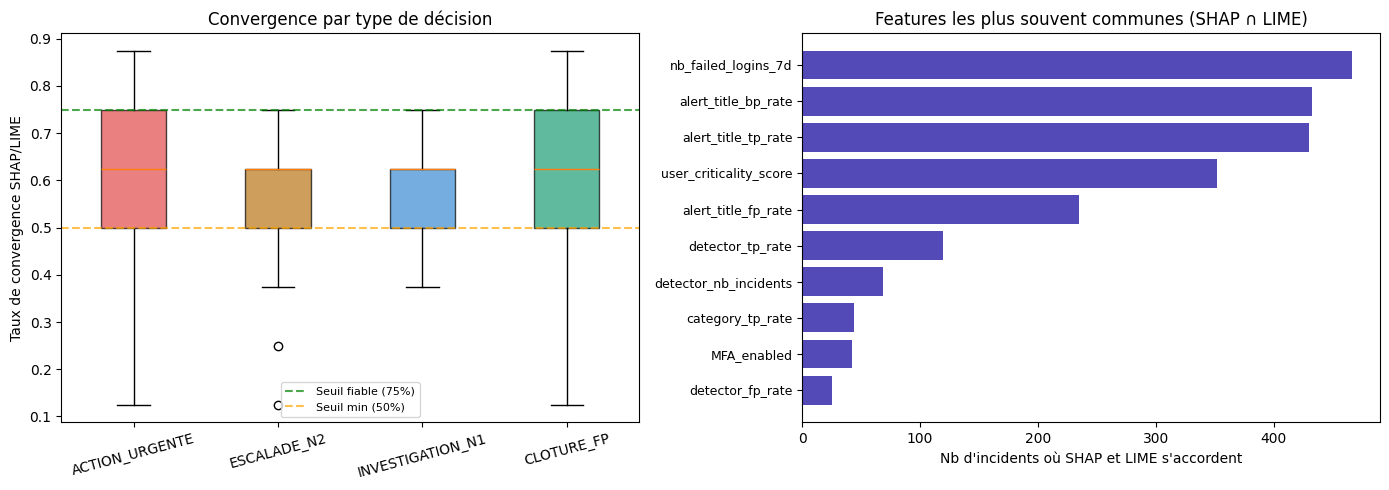


✅ shap_lime_convergence_analysis.png sauvegardé

→ Ces résultats sont utilisables directement dans le mémoire.


In [178]:
# ── Convergence SHAP/LIME par incident et par décision ───────────────────────
convergence_results = []

for idx in range(len(df_sample)):
    if not lime_top_features_sample[idx]:
        continue

    shap_local  = shap_tp_sample[idx]
    shap_series = pd.Series(np.abs(shap_local), index=FEATURE_COLS)
    shap_top    = shap_series.nlargest(N_TOP).index.tolist()
    lime_top    = lime_top_features_sample[idx]

    overlap     = set(shap_top) & set(lime_top)
    convergence = len(overlap) / N_TOP

    convergence_results.append({
        'incident_idx':   idx,
        'IncidentId':     df_sample.iloc[idx]['IncidentId'],
        'decision':       df_sample.iloc[idx]['decision_suggested'],
        'grade_reel':     df_sample.iloc[idx].get('grade_reel_label', '?'),
        'priority_score': df_sample.iloc[idx]['priority_score'],
        'convergence':    convergence,
        'n_overlap':      len(overlap),
        'shap_top':       shap_top,
        'lime_top':       lime_top,
        'common':         sorted(overlap),
    })

conv_df = pd.DataFrame(convergence_results)

if conv_df.empty:
    print("⚠ Aucun résultat — vérifier que LIME a bien tourné (cellule précédente).")
    print(f"  Entrées LIME non-vides : {sum(1 for x in lime_top_features_sample if x)}")
else:
    conv_df['convergence'] = pd.to_numeric(conv_df['convergence'], errors='coerce').fillna(0)

    # ── Résultats globaux ─────────────────────────────────────────────────────
    print("=" * 60)
    print("CONVERGENCE SHAP/LIME — Résultats globaux")
    print("=" * 60)
    print(f"Incidents analysés : {len(conv_df)}")
    print(f"Convergence moyenne globale : {conv_df['convergence'].mean():.1%}")
    print(f"  >= 75% (fiable)   : {(conv_df['convergence'] >= 0.75).sum():3d} incidents "
          f"({(conv_df['convergence'] >= 0.75).mean():.1%})")
    print(f"  50-74% (partiel)  : {((conv_df['convergence'] >= 0.50) & (conv_df['convergence'] < 0.75)).sum():3d} incidents")
    print(f"  < 50%  (faible)   : {(conv_df['convergence'] < 0.50).sum():3d} incidents "
          f"({(conv_df['convergence'] < 0.50).mean():.1%})")

    # ── Par type de décision ──────────────────────────────────────────────────
    print()
    print("=" * 60)
    print("CONVERGENCE PAR TYPE DE DÉCISION")
    print("=" * 60)
    decision_order = ['ACTION_URGENTE', 'ESCALADE_N2', 'INVESTIGATION_N1', 'CLOTURE_FP']
    for dec in decision_order:
        subset = conv_df[conv_df['decision'] == dec]
        if len(subset) == 0:
            continue
        mean_conv  = subset['convergence'].mean()
        pct_fiable = (subset['convergence'] >= 0.75).mean()
        print(f"  {dec:<20} : N={len(subset):3d} | "
              f"conv. moy. = {mean_conv:.1%} | "
              f">= 75% = {pct_fiable:.1%}")

    # ── Features les plus souvent communes ───────────────────────────────────
    print()
    print("=" * 60)
    print("FEATURES LES PLUS SOUVENT COMMUNES (SHAP ∩ LIME)")
    print("=" * 60)
    from collections import Counter
    all_common = []
    for row in convergence_results:
        all_common.extend(row['common'])
    common_counts = Counter(all_common)
    for feat, cnt in common_counts.most_common(10):
        print(f"  {feat:<35} {cnt:3d} fois ({cnt/len(conv_df):.0%})")

    # ── Visualisation ─────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    decision_colors = {
        'ACTION_URGENTE':   '#E24B4A',
        'ESCALADE_N2':      '#BA7517',
        'INVESTIGATION_N1': '#3B8BD4',
        'CLOTURE_FP':       '#1D9E75',
    }
    data_box   = [conv_df[conv_df['decision'] == d]['convergence'].values
                  for d in decision_order if d in conv_df['decision'].values]
    labels_box = [d for d in decision_order if d in conv_df['decision'].values]

    bp = axes[0].boxplot(data_box, labels=labels_box, patch_artist=True)
    for patch, label in zip(bp['boxes'], labels_box):
        patch.set_facecolor(decision_colors.get(label, '#888'))
        patch.set_alpha(0.7)
    axes[0].axhline(0.75, color='green',  linestyle='--', alpha=0.7, label='Seuil fiable (75%)')
    axes[0].axhline(0.50, color='orange', linestyle='--', alpha=0.7, label='Seuil min (50%)')
    axes[0].set_ylabel('Taux de convergence SHAP/LIME')
    axes[0].set_title('Convergence par type de décision')
    axes[0].legend(fontsize=8)
    axes[0].tick_params(axis='x', rotation=15)

    top_common      = common_counts.most_common(10)
    feat_names_plot = [f[:25] for f, _ in top_common]
    feat_counts     = [cnt for _, cnt in top_common]
    axes[1].barh(range(len(feat_names_plot)), feat_counts, color='#534AB7')
    axes[1].set_yticks(range(len(feat_names_plot)))
    axes[1].set_yticklabels(feat_names_plot, fontsize=9)
    axes[1].invert_yaxis()
    axes[1].set_xlabel("Nb d'incidents où SHAP et LIME s'accordent")
    axes[1].set_title('Features les plus souvent communes (SHAP ∩ LIME)')

    plt.tight_layout()
    plt.savefig(DATA_DIR / 'shap_lime_convergence_analysis.png', dpi=120, bbox_inches='tight')
    plt.show()

    print("\n✅ shap_lime_convergence_analysis.png sauvegardé")
    print("\n→ Ces résultats sont utilisables directement dans le mémoire.")


## 5. Génération du texte d'explication pour la démo
Chaque incident reçoit une explication en langage naturel, prête à afficher dans Streamlit.

In [179]:
def generate_explanation_text(incident_row, shap_local, feature_names):
    """Génère un texte d'explication XAI pour l'analyste."""
    contrib = pd.Series(shap_local, index=feature_names).sort_values(key=abs, ascending=False)
    top_pos = contrib[contrib > 0].head(3)
    top_neg = contrib[contrib < 0].head(2)

    score = incident_row.get('priority_score', 0)
    decision = incident_row.get('decision_suggested', 'INVESTIGATION_N1')

    lines = []
    lines.append(f"**Score de priorisation : {score:.0f}/100** — Décision suggérée : {decision}")
    lines.append("")
    lines.append("**Raisons principales (↑ augmente le score) :**")
    for feat, val in top_pos.items():
        feat_val = incident_row[feat] if feat in incident_row.index else '?'
        formatted_val = f"{feat_val:.2f}" if isinstance(feat_val, float) else feat_val
        lines.append(f"  • {feat} = {formatted_val} → +{val:.3f}")

    if len(top_neg) > 0:
        lines.append("")
        lines.append("**Éléments qui réduisent le score (↓) :**")
        for feat, val in top_neg.items():
            feat_val = incident_row[feat] if feat in incident_row.index else '?'
            formatted_val = f"{feat_val:.2f}" if isinstance(feat_val, float) else feat_val
            lines.append(f"  • {feat} = {formatted_val} → {val:.3f}")

    return "\n".join(lines)

# Générer les explications pour les 500 incidents de la démo
explanations = []
for i, (_, row) in enumerate(df_sample.iterrows()):
    shap_local = shap_tp_sample[i]
    text = generate_explanation_text(row, shap_local, FEATURE_COLS)
    explanations.append({'IncidentId': row['IncidentId'], 'explanation_text': text})

explanations_df = pd.DataFrame(explanations)
explanations_df.to_csv(DATA_DIR / 'explanations_sample.csv', index=False)
print(f'✅ explanations_sample.csv : {len(explanations_df):,} explications (démo)')

# Afficher un exemple
print('\nExemple d\'explication (incident critique) :')
print('-' * 50)
print(explanations_df.iloc[0]['explanation_text'])

✅ explanations_sample.csv : 500 explications (démo)

Exemple d'explication (incident critique) :
--------------------------------------------------
**Score de priorisation : 100/100** — Décision suggérée : ACTION_URGENTE

**Raisons principales (↑ augmente le score) :**
  • nb_failed_logins_7d = 14.00 → +1.646
  • alert_title_tp_rate = 0.97 → +1.497
  • user_criticality_score = 2 → +0.667

**Éléments qui réduisent le score (↓) :**
  • alerts_per_detector = 1.50 → -0.028
  • nb_alerts = 3 → -0.025


In [180]:
print('\n✅ Notebook XAI terminé. Fichiers générés :')
print('  data/shap_values_sample.pkl')
print('  data/explanations_sample.csv')
print('  data/shap_summary_tp.png')
print('  data/shap_importance_bar.png')
print('  data/shap_waterfall_critique.png')
print('  data/shap_waterfall_fp.png')
print('  data/counterfactuals.png')
print('  data/lime_critique.png')
print('  data/shap_vs_lime_critique.png')
print('  data/lime_values_sample.pkl')
print('  data/shap_lime_convergence_analysis.png')
print('\n→ Prochaine étape : streamlit run 05_demo_app.py')


✅ Notebook XAI terminé. Fichiers générés :
  data/shap_values_sample.pkl
  data/explanations_sample.csv
  data/shap_summary_tp.png
  data/shap_importance_bar.png
  data/shap_waterfall_critique.png
  data/shap_waterfall_fp.png
  data/counterfactuals.png
  data/lime_critique.png
  data/shap_vs_lime_critique.png
  data/lime_values_sample.pkl
  data/shap_lime_convergence_analysis.png

→ Prochaine étape : streamlit run 05_demo_app.py
